In [2]:
import polars as pl
import numpy as np # For inf and sqrt, polyfit, corrcoef
import plotly.express as px
import plotly.graph_objects as go
from typing import Optional, Dict, Any # For type hinting
import os # Added for file existence check and removal

print(f"Polars version: {pl.__version__}")

# --- Core Data Loading and Filtering ---

def extract_records_with_old_dpf_pl(
    csv_file: str,
    min_dpf: int = 15,
    output_file: Optional[str] = None
) -> Optional[pl.DataFrame]:
    """
    Extracts records using Polars where days post-fertilization (dpf) exceeds a threshold.

    Uses Polars' lazy API for efficient filtering and aggregation. Addresses warnings.

    Parameters:
    -----------
    csv_file : str
        Path to the CSV file containing the survival data.
    min_dpf : int
        Minimum days post-fertilization threshold (default: 15).
    output_file : str, optional
        If provided, saves the filtered results to this CSV file.

    Returns:
    --------
    polars.DataFrame or None
        DataFrame containing filtered records, or None if input column is missing or error occurs.
    """
    print(f"Scanning data from {csv_file} using Polars...")
    try:
        # Start with a lazy scan of the CSV
        lf = pl.scan_csv(csv_file)

        # --- Fix for PerformanceWarning ---
        # Explicitly collect schema to check columns without performance warning
        schema_cols = lf.collect_schema().names()
        if 'days_since_fertilization' not in schema_cols:
            print(f"Error: 'days_since_fertilization' column not found in {csv_file}.")
            return None
        # --- End Fix ---

        # Define the filtering operation lazily
        lf_filtered = lf.filter(pl.col('days_since_fertilization') >= min_dpf)

        # --- Eager execution needed for summaries & saving ---
        # Collect the filtered results into a DataFrame
        print("Applying filter...")
        old_records = lf_filtered.collect()

        # --- Summaries ---
        total_filtered_records = old_records.height
        if total_filtered_records == 0:
             print(f"\nNo records found where days post-fertilization >= {min_dpf}")
             unique_dishes_count = 0
        else:
            # Check if 'dish_id' exists before calculating unique count
            if 'dish_id' not in old_records.columns:
                 print("Warning: 'dish_id' column not found for summary.")
                 unique_dishes_count = 'N/A'
                 dish_counts = None
            else:
                unique_dishes_count = old_records['dish_id'].n_unique()
                print(f"\nFound {total_filtered_records} records where days post-fertilization >= {min_dpf}")
                print(f"These records come from {unique_dishes_count} unique dishes")

                # Calculate counts per dish_id efficiently
                # --- Fix for DeprecationWarning ---
                dish_counts = old_records.group_by('dish_id').agg(
                    pl.len().alias('record_count') # Use pl.len() instead of pl.count()
                ).sort('dish_id') # Sort for consistent output
                # --- End Fix ---

                print(f"\nUnique dish IDs and record counts (dpf >= {min_dpf}):")
                # Iterate through the small summary DataFrame to print
                for row in dish_counts.iter_rows(named=True):
                     print(f"  - {row['dish_id']}: {row['record_count']} records")

        # Save to output file if specified (using Polars writer)
        if output_file:
            if total_filtered_records > 0:
                try:
                    old_records.write_csv(output_file)
                    print(f"\nSaved filtered records to {output_file}")
                except Exception as e:
                    print(f"\nError saving file to {output_file}: {e}")
            else:
                 print(f"\nSkipping save to {output_file} as no records were filtered.")


        return old_records

    except FileNotFoundError:
        print(f"Error: Input file not found at {csv_file}")
        return None
    except Exception as e:
        # Catch other potential Polars errors during scan/collect
        print(f"An error occurred during processing: {e}")
        return None


# --- Date Conversion ---

def convert_date_columns_pl(df: pl.DataFrame) -> pl.DataFrame:
    """
    Converts specified date columns (read as Int64FormProviderMMDD) to Date type in Polars.
    Handles potential nulls or zeros.

    Parameters:
    -----------
    df : pl.DataFrame
        Input DataFrame with date columns inFormProviderMMDD format (as Int64 or Utf8).

    Returns:
    --------
    pl.DataFrame
        DataFrame with specified columns converted to Polars Date type.
    """
    print("Converting date columns (YYYYMMDD -> Date)...")
    # --- Updated list based on head() output ---
    date_cols_to_convert = ['date_fertilized', 'date_created', 'check_date', 'termination_date']
    # --- End Update ---

    # Build expressions dynamically
    conversion_exprs = []
    found_cols_count = 0
    for col_name in date_cols_to_convert:
        if col_name in df.columns:
            found_cols_count += 1
            conversion_exprs.append(
                pl.when(pl.col(col_name).is_null() | (pl.col(col_name) == 0)) # Handle nulls/zeros first
                .then(pl.lit(None, dtype=pl.Date)) # Result is a null Date
                .otherwise(
                    pl.col(col_name)
                    .cast(pl.Utf8, strict=False) # Cast valid numbers/strings to Utf8 string safely
                    .str.strptime(pl.Date, format="%Y%m%d", strict=False) # Parse string to Date
                    # strict=False makes parsing errors return null, similar to errors='coerce'
                )
                .alias(col_name) # Overwrite existing column
            )
        else:
            print(f"Warning: Column '{col_name}' not found for date conversion.")

    if not conversion_exprs:
        print("No date columns found or specified for conversion.")
        return df # Return original df if no columns to convert

    print(f"Applying conversion to {found_cols_count} date column(s).")
    return df.with_columns(conversion_exprs)


# --- Derivative Calculation ---

def calculate_survival_derivatives_pl(df: pl.DataFrame) -> pl.DataFrame:
    """
    Calculates the day-to-day change in survival rate per dish_id using Polars window functions.
    Uses pl.col(col).shift(n).over(group) syntax as an alternative for older Polars versions.

    Assumes input DataFrame has 'dish_id', 'days_since_fertilization', 'survival_rate'.

    Parameters:
    -----------
    df : pl.DataFrame
        Input DataFrame.

    Returns:
    --------
    pl.DataFrame
        DataFrame with an added 'survival_rate_change' column.
    """
    print("Calculating survival rate derivatives using Polars (shift().over() approach)...") # Updated print message

    # Check for required columns
    required_cols = ['dish_id', 'days_since_fertilization', 'survival_rate']
    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        print(f"Error: Missing required columns for derivative calculation: {missing}")
        # Add null column and return if needed, or raise error
        return df.with_columns(pl.lit(None, dtype=pl.Float64).alias('survival_rate_change'))

    # Use lazy evaluation for optimal performance
    lazy_df = df.lazy()

    # Define the calculation using window functions within with_columns
    # Window functions in Polars require the data to be sorted within the partition.
    result_lf = lazy_df.sort('dish_id', 'days_since_fertilization').with_columns(
        # --- Attempting shift().over() syntax ---
        # This gets the value from the previous row within the 'dish_id' partition
        pl.col('survival_rate').shift(1).over('dish_id').alias('prev_survival_rate'),
        pl.col('days_since_fertilization').shift(1).over('dish_id').alias('prev_days')
        # --- End shift().over() attempt ---
    ).with_columns(
        # Calculate the change (derivative)
        pl.when(pl.col('prev_days').is_not_null() & (pl.col('days_since_fertilization') > pl.col('prev_days')))
        .then(
            (pl.col('survival_rate') - pl.col('prev_survival_rate')) /
            (pl.col('days_since_fertilization') - pl.col('prev_days'))
        )
        .otherwise(None) # Set derivative to null for the first record or if days don't increase
        .alias('survival_rate_change')
    ).drop(['prev_survival_rate', 'prev_days']) # Remove temporary columns

    # Execute the lazy plan and return the result
    print("Collecting derivative results...") # Add print before collect
    try:
        result_df = result_lf.collect()
        print("Derivative calculation complete.")
        return result_df
    except Exception as e:
        print(f"Error during derivative calculation/collection: {e}")
        # Return original df with null column in case of error during this step
        return df.with_columns(pl.lit(None, dtype=pl.Float64).alias('survival_rate_change'))


# --- Density Calculation ---

def calculate_density_pl(df: pl.DataFrame) -> pl.DataFrame:
    """
    Calculate fish density metrics and categorize based on volume per fish using Polars.
    Uses when/then/otherwise instead of pl.cut for broader version compatibility.
    """
    print("Calculating density metrics using Polars (when/then approach)...")

    required_cols = ['initial_count', 'vol_water_total']
    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        print(f"Warning: Missing required columns for density calculation: {missing}. Skipping.")
        # Add null columns if they don't exist
        cols_to_add = {}
        if 'fish_density' not in df.columns:
             cols_to_add['fish_density'] = pl.lit(None, dtype=pl.Float64)
        if 'volume_per_fish' not in df.columns:
             cols_to_add['volume_per_fish'] = pl.lit(None, dtype=pl.Float64)
        if 'density_category' not in df.columns:
             cols_to_add['density_category'] = pl.lit(None, dtype=pl.Categorical)
        return df.with_columns(**cols_to_add) if cols_to_add else df

    return df.with_columns(
        # Ensure columns are numeric (Float64 for division), coerce errors to null
        pl.col('initial_count').cast(pl.Float64, strict=False).alias('initial_count_num'),
        pl.col('vol_water_total').cast(pl.Float64, strict=False).alias('vol_water_total_num')
    ).with_columns(
        # Calculate density metrics, handle division by zero or nulls
        pl.when((pl.col('vol_water_total_num') != 0) & pl.col('vol_water_total_num').is_not_null() & pl.col('initial_count_num').is_not_null())
        .then(pl.col('initial_count_num') / pl.col('vol_water_total_num'))
        .otherwise(None) # fish per mL
        .alias('fish_density'),

        pl.when((pl.col('initial_count_num') != 0) & pl.col('initial_count_num').is_not_null() & pl.col('vol_water_total_num').is_not_null())
        .then(pl.col('vol_water_total_num') / pl.col('initial_count_num'))
        .otherwise(None) # mL per fish
        .alias('volume_per_fish')
    ).with_columns(
        # --- Fix for pl.cut AttributeError ---
        # Create density categories using chained when/then/otherwise
        pl.when(pl.col('volume_per_fish').is_null())
        .then(pl.lit(None)) # Keep nulls as null
        .when(pl.col('volume_per_fish') <= 2)
        .then(pl.lit('Very High (<2mL/fish)'))
        .when(pl.col('volume_per_fish') <= 3) # Already known > 2
        .then(pl.lit('High (2-3mL/fish)'))
        .when(pl.col('volume_per_fish') <= 4) # Already known > 3
        .then(pl.lit('Medium (3-4mL/fish)'))
        .otherwise(pl.lit('Low (>4mL/fish)')) # Handles > 4
        .cast(pl.Categorical) # Cast the final result to Categorical
        .alias('density_category')
        # --- End Fix ---
    ).drop(['initial_count_num', 'vol_water_total_num']) # Drop temporary numeric columns


# --- Plotting Functions Adapted for Polars ---

def plot_survival_curves_pl(
    df: pl.DataFrame,
    color_by_density: bool = False,
    visible_conditions: Optional[Dict[str, bool]] = None
) -> go.Figure:
    """Plot survival curves over time using Polars DataFrame and Plotly."""
    print(f"Plotting survival curves (color_by_density={color_by_density})...")
    plot_df = df # Polars DataFrames are immutable, no copy needed for plotting

    color_col = None
    title = ""
    legend_title = ""

    # Determine color column and handle combined genotype/housing
    if color_by_density and 'density_category' in plot_df.columns:
        color_col = 'density_category'
        title = 'Survival Curves by Fish Density'
        legend_title = 'Fish Density'
        # Ensure categorical type for consistent plotting
        plot_df = plot_df.with_columns(pl.col(color_col).cast(pl.Categorical))
    # --- Updated condition for in_beaker (str 'Yes'/'No') ---
    elif 'in_beaker' in plot_df.columns and 'genotype' in plot_df.columns:
        # Create combined column efficiently using expressions
        plot_df = plot_df.with_columns(
            pl.when(pl.col('in_beaker').str.to_lowercase() == 'yes') # Check for 'yes' string
            .then(pl.concat_str([pl.col('genotype'), pl.lit(' (beaker)')]))
            .otherwise(pl.concat_str([pl.col('genotype'), pl.lit(' (dish)')]))
            .alias('genotype_housing')
            .cast(pl.Categorical) # Cast to categorical
        )
        color_col = 'genotype_housing'
        title = 'Survival Curves by Genotype and Housing Type'
        legend_title = 'Genotype & Housing'
    # --- End Update ---
    elif 'genotype' in plot_df.columns:
        color_col = 'genotype'
        title = 'Survival Curves by Genotype'
        legend_title = 'Genotype'
        plot_df = plot_df.with_columns(pl.col(color_col).cast(pl.Categorical))
    else:
        # Fallback if no suitable color column found
        print("Warning: No suitable column found for coloring survival curves.")
        # Plot without color, or return an empty figure
        fig = px.line(
            plot_df.to_pandas(), # px.line might need pandas for complex cases without color
            x='days_since_fertilization',
            y='survival_rate',
            line_group='dish_id',
            title='Survival Curves (No Grouping)',
            labels={'days_since_fertilization': 'Days Since Fertilization', 'survival_rate': 'Survival Rate (%)'}
        )
        fig.update_layout(yaxis=dict(range=[0, 100]), height=600, width=1000)
        return fig

    # --- Create the main line plot ---
    # Plotly Express often works directly with Polars DataFrames
    fig = px.line(
        plot_df, # Use Polars DataFrame directly
        x='days_since_fertilization',
        y='survival_rate',
        color=color_col,
        line_group='dish_id',
        hover_data=['dish_id', 'genotype', 'initial_count', 'volume_per_fish', 'vol_water_total', 'in_beaker'],
        labels={
            'days_since_fertilization': 'Days Since Fertilization',
            'survival_rate': 'Survival Rate (%)',
             # Dynamically set label based on color_col if needed, px usually handles this
        },
        title=title,
        color_discrete_sequence=px.colors.qualitative.Plotly # Example sequence
    )

    # --- Add mean survival curves ---
    if color_col in plot_df.columns:
        # Calculate means efficiently using Polars group_by
        mean_curves_df = plot_df.group_by([color_col, 'days_since_fertilization']).agg(
            pl.mean('survival_rate').alias('mean_survival_rate')
        ).sort(color_col, 'days_since_fertilization')

        # Get unique categories and map them to colors used by Plotly
        unique_cats = plot_df[color_col].drop_nulls().unique().sort().to_list()
        # Handle cases where number of unique cats doesn't match number of traces
        color_map = {}
        trace_index = 0
        processed_cats = set()
        # Try to safely map colors based on trace names
        try:
            for trace in fig.data:
                 # Extract category name (might need adjustment based on Plotly naming)
                 # Check if trace name is in unique_cats before proceeding
                 cat_name = trace.name
                 if cat_name in unique_cats and cat_name not in processed_cats:
                      color_map[cat_name] = trace.line.color
                      processed_cats.add(cat_name)
                      trace_index += 1
        except Exception as e:
             print(f"Warning: Could not reliably map colors for mean lines - {e}")
             color_map = {} # Reset map if error occurs

        # Add mean traces
        for cat in unique_cats:
            cat_means = mean_curves_df.filter(pl.col(color_col) == cat)
            if cat_means.height > 0: # Ensure there's data for the mean trace
                cat_color = color_map.get(cat, 'grey') # Fallback color
                fig.add_trace(
                    go.Scatter(
                        x=cat_means['days_since_fertilization'],
                        y=cat_means['mean_survival_rate'],
                        mode='lines',
                        line=dict(width=4, dash='dash', color=cat_color), # Use matching color
                        name=f'{cat} (mean)',
                        legendgroup=cat, # Group mean line with its category
                        showlegend=True # Decide if mean lines need separate legend items
                    )
                )

    # --- Apply visibility settings ---
    if visible_conditions and color_col:
        # This part is tricky as trace names/order might vary.
        # It's often easier to filter the DataFrame *before* plotting in dashboard contexts.
        # However, attempting to match Plotly's trace naming:
        print("Applying visibility conditions (Note: Best effort based on trace names)")
        traces_to_keep = []
        for condition, is_visible in visible_conditions.items():
             if is_visible:
                  traces_to_keep.append(condition)
                  traces_to_keep.append(f"{condition} (mean)") # Also keep mean trace

        fig.for_each_trace(lambda trace: trace.update(visible=True) if trace.name in traces_to_keep else trace.update(visible=False))


    # Update layout
    fig.update_layout(
        xaxis_title='Days Since Fertilization',
        yaxis_title='Survival Rate (%)',
        yaxis=dict(range=[0, 100]), # Assuming survival rate is 0-100
        legend_title_text=legend_title,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='closest',
        height=600,
        width=1000
    )

    return fig

def plot_housing_comparison_pl(df: pl.DataFrame) -> go.Figure:
    """Compare survival rates between beaker and dish housing using Polars and Plotly."""
    print("Plotting housing comparison...")
    plot_df = df

    required_cols = ['dish_id', 'days_since_fertilization', 'survival_rate', 'genotype', 'in_beaker']
    if not all(col in plot_df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in plot_df.columns]
        print(f"Warning: Missing required columns for housing comparison: {missing}. Skipping plot.")
        return go.Figure(layout=go.Layout(title="Housing comparison not available - Required columns missing"))

    # --- Updated condition for in_beaker (str 'Yes'/'No') ---
    # Create housing type column using Polars expressions
    plot_df = plot_df.with_columns(
        pl.when(pl.col('in_beaker').str.to_lowercase() == 'yes') # Check for 'yes' string
        .then(pl.lit('Beaker'))
        .otherwise(pl.lit('Dish'))
        .alias('housing')
        .cast(pl.Categorical)
    )
    # --- End Update ---

    # Get the latest record for each dish using Polars window function or filter
    latest_records = plot_df.filter(
        pl.col('days_since_fertilization') == pl.max('days_since_fertilization').over('dish_id')
    )
    # Alternative using sort().last(): latest_records = plot_df.sort('days_since_fertilization').last().over('dish_id')

    # Calculate average final survival rate, std dev, count, and SE by genotype and housing
    summary = latest_records.group_by(['genotype', 'housing']).agg(
        pl.mean('survival_rate').alias('mean'),
        pl.std('survival_rate').alias('std'),
        pl.len().alias('count') # Use pl.len() for count
    ).with_columns(
        # Calculate standard error, handle potential null std or count <= 0
        pl.when(pl.col('count') > 0)
        .then(pl.col('std') / pl.col('count').sqrt())
        .otherwise(None)
        .alias('se')
    ).sort('genotype', 'housing')

    # --- Create bar chart ---
    # Plotly Express works well here
    fig = px.bar(
        summary, # Use Polars df directly
        x='genotype',
        y='mean',
        color='housing',
        barmode='group',
        error_y='se', # Add error bars using 'se' column
        labels={
            'mean': 'Final Survival Rate (%)',
            'genotype': 'Genotype',
            'housing': 'Housing Type'
        },
        title='Comparison of Final Survival Rates by Genotype and Housing Type'
    )

    # --- Add individual data points ---
    # Plotly Express can sometimes add points, but manual add_trace gives more control
    # Note: px.strip is also an option for showing individual points alongside bars/boxplots
    if latest_records.height > 0 and summary.height > 0: # Check if data exists
        try:
            # Safely map colors based on legend names created by px.bar
            color_discrete_map = {trace.name: trace.marker.color for trace in fig.data if trace.name in ['Beaker', 'Dish']}
        except Exception as e:
             print(f"Warning: Could not map bar colors for individual points - {e}")
             color_discrete_map = {} # Use fallback if mapping fails

        for housing_type in ['Beaker', 'Dish']:
            housing_data = latest_records.filter(pl.col('housing') == housing_type)
            if housing_data.height > 0: # Only add trace if data exists
                 bar_color = color_discrete_map.get(housing_type, 'grey') # Get color from bar trace or fallback

                 fig.add_trace(
                     go.Scatter(
                         x=housing_data['genotype'],
                         y=housing_data['survival_rate'],
                         mode='markers',
                         marker=dict(
                             size=8,
                             opacity=0.7,
                             line=dict(width=1, color='black'),
                             color=bar_color # Match bar color
                         ),
                         name=f'{housing_type} (individual)',
                         legendgroup=housing_type, # Group with corresponding bar
                         showlegend=True # Or False if too cluttered
                     )
                 )

    # Update layout
    fig.update_layout(
        xaxis_title='Genotype',
        yaxis_title='Survival Rate (%)',
        yaxis=dict(range=[0, 100]),
        legend_title_text='Housing Type',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='closest',
        height=600,
        width=1000
    )

    return fig


def plot_density_vs_survival_pl(
    df: pl.DataFrame,
    days: Optional[int] = None,
    use_volume_per_fish: bool = True,
    visible_conditions: Optional[Dict[str, bool]] = None
) -> go.Figure:
    """
    Create a scatter plot (density vs survival) using Polars and Plotly.
    """
    print(f"Plotting density vs survival (use_volume_per_fish={use_volume_per_fish})...")
    plot_df = df

    # Check required columns
    required_base = ['dish_id', 'days_since_fertilization', 'survival_rate', 'genotype', 'initial_count']
    required_density = ['volume_per_fish'] if use_volume_per_fish else ['fish_density']
    if not all(col in plot_df.columns for col in required_base + required_density):
         missing = [col for col in required_base + required_density if col not in plot_df.columns]
         print(f"Warning: Missing required columns for density vs survival plot: {missing}. Skipping plot.")
         return go.Figure(layout=go.Layout(title="Density vs Survival plot not available - Required columns missing"))


    # Filter for specific day or get latest records
    if days is not None:
        plot_df = plot_df.filter(pl.col('days_since_fertilization') == days)
        plot_title_suffix = f' (Day {days})'
    else:
        # Get the latest record for each dish
        plot_df = plot_df.filter(
            pl.col('days_since_fertilization') == pl.max('days_since_fertilization').over('dish_id')
        )
        plot_title_suffix = ' (Latest Measurement)'

    # Choose density metric column and label
    if use_volume_per_fish:
        x_column = 'volume_per_fish'
        x_label = 'Volume per Fish (mL/fish)'
    else:
        x_column = 'fish_density'
        x_label = 'Fish Density (fish/mL)'

    plot_title = f'{"Volume per Fish" if use_volume_per_fish else "Fish Density"} vs Survival Rate{plot_title_suffix}'

    # --- Filter based on visible conditions (genotypes) BEFORE plotting/regression ---
    plot_df_filtered = plot_df # Start with potentially day-filtered data
    if visible_conditions:
        visible_genotypes = [gen for gen, visible in visible_conditions.items() if visible]
        if visible_genotypes: # Only filter if list is not empty
             plot_df_filtered = plot_df_filtered.filter(pl.col('genotype').is_in(visible_genotypes))
        else: # If all are turned off, plot nothing
             plot_df_filtered = plot_df_filtered.clear()


    # --- Create scatter plot ---
    # Ensure data exists after filtering before plotting
    if plot_df_filtered.height == 0:
         print("Warning: No data left after filtering for visible conditions.")
         return go.Figure(layout=go.Layout(title=f"{plot_title} - No data to display"))

    fig = px.scatter(
        plot_df_filtered, # Use the filtered data
        x=x_column,
        y='survival_rate',
        color='genotype',
        size='initial_count', # Size bubbles by initial count
        hover_data=['dish_id', 'days_since_fertilization', 'vol_water_total', 'in_beaker', 'density_category'],
        labels={
            x_column: x_label,
            'survival_rate': 'Survival Rate (%)',
            'genotype': 'Genotype',
            'initial_count': 'Initial Fish Count',
        },
        title=plot_title
    )

    # --- Add regression line and correlation (based on filtered data) ---
    # Drop nulls needed for regression/correlation calculation
    plot_df_clean = plot_df_filtered.drop_nulls(subset=[x_column, 'survival_rate'])

    if plot_df_clean.height > 1: # Need at least 2 points
        # Extract data to NumPy for polyfit/corrcoef
        x_np = plot_df_clean.get_column(x_column).to_numpy()
        y_np = plot_df_clean.get_column('survival_rate').to_numpy()

        try:
            # Calculate line of best fit
            coeffs = np.polyfit(x_np, y_np, 1)
            # Check for NaN coefficients which can occur with insufficient data variation
            if not np.isnan(coeffs).any():
                line_x = np.array([x_np.min(), x_np.max()])
                line_y = np.polyval(coeffs, line_x) # Use polyval for clarity

                # Add regression line trace
                fig.add_trace(
                    go.Scatter(
                        x=line_x, y=line_y, mode='lines', name=f'Trend (y={coeffs[0]:.2f}x+{coeffs[1]:.2f})',
                        line=dict(color='black', dash='dash')
                    )
                )

                # Calculate correlation
                # Ensure inputs to corrcoef are valid (no NaNs, finite)
                if np.isfinite(x_np).all() and np.isfinite(y_np).all():
                    # Check for zero standard deviation
                    if np.std(x_np) > 0 and np.std(y_np) > 0:
                        correlation = np.corrcoef(x_np, y_np)[0, 1]
                        if not np.isnan(correlation):
                             # Add correlation annotation
                             fig.add_annotation(
                                 x=0.98, y=0.05, xref="paper", yref="paper", text=f"R = {correlation:.3f}", showarrow=False,
                                 font=dict(size=14, color="black"), bgcolor="white", bordercolor="black", borderwidth=1, borderpad=4
                             )
                        else:
                             print("Warning: Correlation calculation resulted in NaN.")
                    else:
                        print("Warning: Zero standard deviation in data; skipping correlation calculation.")
                else:
                     print("Warning: Non-finite values found; skipping correlation calculation.")
            else:
                 print("Warning: Trend line calculation resulted in NaN coefficients.")

        except Exception as e:
            print(f"Could not calculate or add trend line/correlation: {e}")


    # Update layout
    fig.update_layout(
        xaxis_title=x_label,
        yaxis_title='Survival Rate (%)',
        yaxis=dict(range=[0, 100]),
        legend_title_text='Genotype',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
        hovermode='closest',
        height=600,
        width=1000
    )

    return fig


# --- Example Usage ---
if __name__ == "__main__":
    # Define the path to your actual CSV file
    actual_csv_path = "survivability_report.csv"
    filtered_output_path = "filtered_data.csv" # Optional output for old records

    # Check if the input file exists
    if not os.path.exists(actual_csv_path):
        print(f"Error: Input file not found at '{actual_csv_path}'. Please ensure the file exists.")
    else:
        print(f"Processing actual file: {actual_csv_path}")

        # --- Optional: Extract old records ---
        # This step is separate from the main processing pipeline below
        print("\n--- Running extract_records_with_old_dpf_pl ---")
        extract_records_with_old_dpf_pl(actual_csv_path, min_dpf=16, output_file=filtered_output_path)
        # We don't use the returned 'filtered_df' in the subsequent steps here

        # --- Main Processing Pipeline ---
        try:
            print("\n--- Loading and Initial Conversion ---")
            # Load the full dataset for processing
            df_raw = pl.read_csv(actual_csv_path)
            print(f"Loaded {df_raw.height} rows.")

            df_dates_converted = convert_date_columns_pl(df_raw)
            # print("\nConverted Dates Dtypes:\n", df_dates_converted.dtypes) # Optional: view dtypes

            print("\n--- Calculating Density ---")
            df_with_density = calculate_density_pl(df_dates_converted)
            # print("\nDataFrame with Density head:\n", df_with_density.head()) # Optional: view head
            # print("\nDensity Dtypes:\n", df_with_density.dtypes) # Optional: view dtypes

            print("\n--- Calculating Survival Derivatives ---")
            df_final = calculate_survival_derivatives_pl(df_with_density)
            print("\nFinal Processed DataFrame head:\n", df_final.head()) # Show head of final data

            # --- Example Plotting Calls (using the fully processed df_final) ---
            # Note: These calls generate Plotly figures but won't display automatically in a script.
            # You would typically integrate this into a Jupyter notebook, dashboard app (Dash/Streamlit),
            # or explicitly save/show the figures.

            print("\n--- Generating Example Plots (won't display in script) ---")

            # Example 1: Survival Curves by Genotype/Housing
            print("Generating plot 1...")
            fig1 = plot_survival_curves_pl(df_final, color_by_density=False)
            # fig1.show()
            # fig1.write_html("survival_by_genotype_housing.html")

            # Example 2: Survival Curves by Density
            print("Generating plot 2...")
            fig2 = plot_survival_curves_pl(df_final, color_by_density=True)
            # fig2.show()
            # fig2.write_html("survival_by_density.html")

            # Example 3: Housing Comparison
            print("Generating plot 3...")
            fig3 = plot_housing_comparison_pl(df_final)
            # fig3.show()
            # fig3.write_html("housing_comparison.html")

            # Example 4: Density vs Survival Scatter
            print("Generating plot 4...")
            fig4 = plot_density_vs_survival_pl(df_final, use_volume_per_fish=True)
            # fig4.show()
            # fig4.write_html("density_vs_survival.html")

            print("\n--- Plot generation examples complete ---")

        except Exception as e:
            print(f"\nAn error occurred during the main processing pipeline: {e}")


        # Clean up the filtered data file if it was created
        try:
            if os.path.exists(filtered_output_path):
                 os.remove(filtered_output_path)
                 print(f"\nRemoved temporary file: {filtered_output_path}")
        except OSError as e:
            print(f"Error removing temporary file {filtered_output_path}: {e}")

Polars version: 1.26.0
Processing actual file: survivability_report.csv

--- Running extract_records_with_old_dpf_pl ---
Scanning data from survivability_report.csv using Polars...
Applying filter...

Found 10 records where days post-fertilization >= 16
These records come from 5 unique dishes

Unique dish IDs and record counts (dpf >= 16):
  - 15016_1: 1 records
  - 15016_2: 1 records
  - 15016_3: 1 records
  - 15016_4: 1 records
  - 15091_6: 6 records

Saved filtered records to filtered_data.csv

--- Loading and Initial Conversion ---
Loaded 409 rows.
Converting date columns (YYYYMMDD -> Date)...
Applying conversion to 4 date column(s).

--- Calculating Density ---
Calculating density metrics using Polars (when/then approach)...

--- Calculating Survival Derivatives ---
Calculating survival rate derivatives using Polars (shift().over() approach)...
Derivative calculation complete.

Final Processed DataFrame head:
 shape: (5, 25)
┌─────────┬──────────┬────────────┬────────────┬───┬────

In [15]:
import polars as pl
import os # Assuming os is needed from the previous context

# --- Assume df_final is your fully processed Polars DataFrame ---
# Example: Load data and process it (replace with your actual loading/processing)
actual_csv_path = "survivability_report.csv"
if os.path.exists(actual_csv_path):
    try:
        print("Loading data...")
        df_raw = pl.read_csv(actual_csv_path)
        # --- Apply your processing functions ---
        # df_dates_converted = convert_date_columns_pl(df_raw)
        # df_with_density = calculate_density_pl(df_dates_converted)
        # df_final = calculate_survival_derivatives_pl(df_with_density)
        # For demonstration, let's just use df_raw or a processed version if available
        # Replace df_to_show with your actual final DataFrame (e.g., df_final)
        df_to_show = df_raw
        print("Data loaded/processed.")

        # --- Display the full head ---
        print("\n--- Displaying head() with expanded view ---")
        # Use the context manager to temporarily set display options
        with pl.Config(
            tbl_rows=20,          # Show more rows (e.g., 20, or -1 for potentially all)
            tbl_cols=-1,          # Show all columns (-1 means no limit)
            fmt_str_lengths=100,  # Show more characters within each string cell
            tbl_width_chars=500   # Allow table to be wider horizontally
        ) as cfg: # The 'as cfg' part is optional but good practice
            # Print the head (e.g., first 10 rows) within the context
            print(df_to_show.head(10))

        print("\n--- Display settings automatically reset outside 'with' block ---")

    except FileNotFoundError:
         print(f"Error: File not found '{actual_csv_path}'")
    except Exception as e:
         print(f"An error occurred: {e}")
else:
    print(f"Error: File not found '{actual_csv_path}'")


Loading data...
Data loaded/processed.

--- Displaying head() with expanded view ---
shape: (10, 21)
┌─────────┬──────────┬─────────────┬─────────────────┬──────────────┬───────────────┬────────────┬─────────────┬───────────────────┬───────────┬───────────────┬──────────────────────────┬──────────┬──────────────────┬────────────────────┬──────────────────┬───────────┬─────────────────┬─────────────┬───────────────┬───────────────────┐
│ dish_id ┆ cross_id ┆ genotype    ┆ date_fertilized ┆ date_created ┆ initial_count ┆ check_date ┆ fish_deaths ┆ cumulative_deaths ┆ remaining ┆ survival_rate ┆ days_since_fertilization ┆ status   ┆ termination_date ┆ termination_reason ┆ responsible      ┆ in_beaker ┆ vol_water_total ┆ room        ┆ water_changed ┆ vol_water_changed │
│ ---     ┆ ---      ┆ ---         ┆ ---             ┆ ---          ┆ ---           ┆ ---        ┆ ---         ┆ ---               ┆ ---       ┆ ---           ┆ ---                      ┆ ---      ┆ ---              ┆ ---  

# Functions End

Now, let's load the survival data:

/tmp/ipykernel_49435/1834348697.py:27: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_49435/1834348697.py:54: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



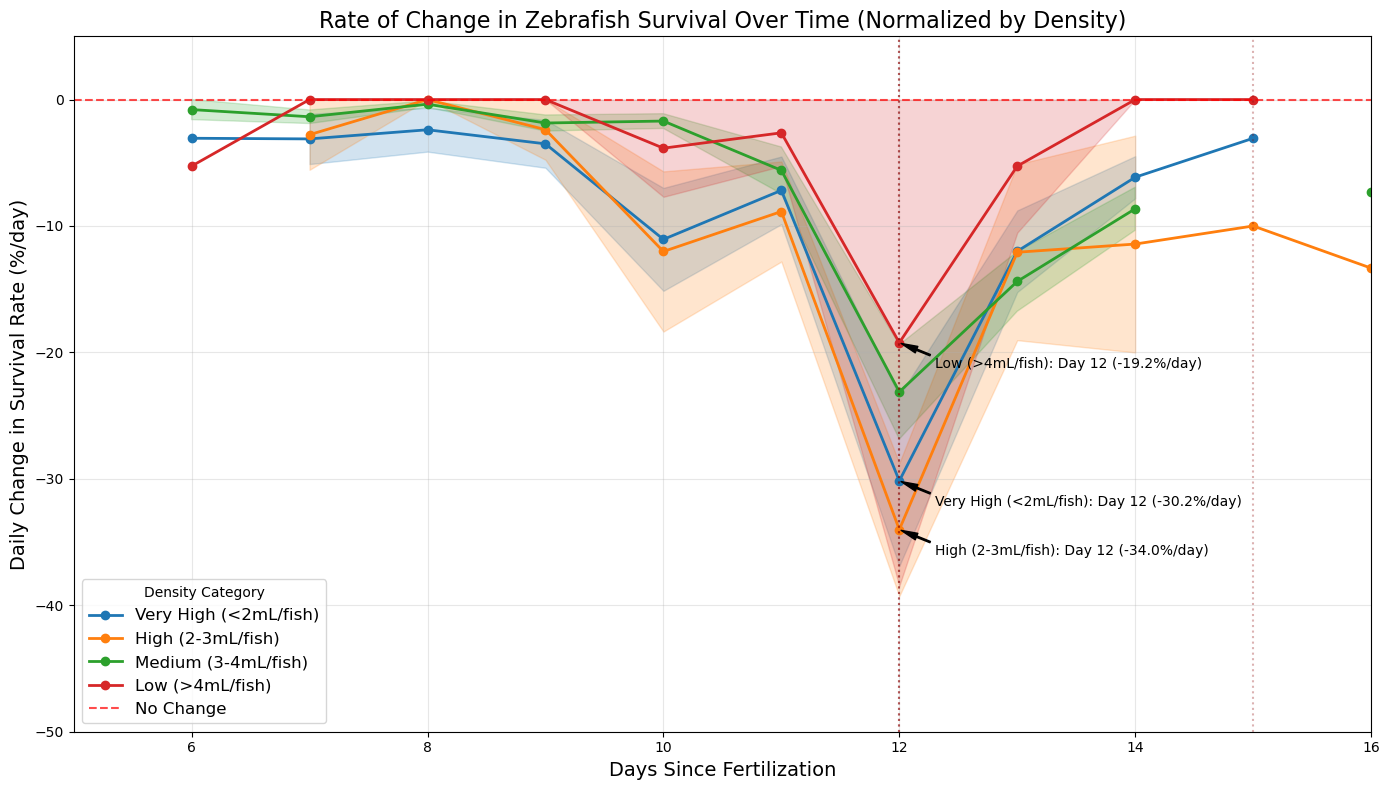

Statistical analysis of critical periods by density category:
                      critical_day                 max_decline             \
                              mean       std count        mean        std   
density_category                                                            
Very High (<2mL/fish)    11.714286  0.755929     7  -30.872615  17.118267   
High (2-3mL/fish)        12.250000  0.500000     4  -36.792891   5.797819   
Medium (3-4mL/fish)      12.464286  1.035737    28        -inf        NaN   
Low (>4mL/fish)          12.500000  0.707107     2  -24.493927  19.753185   

                             
                      count  
density_category             
Very High (<2mL/fish)     7  
High (2-3mL/fish)         4  
Medium (3-4mL/fish)      28  
Low (>4mL/fish)           2  


/tmp/ipykernel_49435/1834348697.py:90: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_49435/1834348697.py:90: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/tmp/ipykernel_49435/1834348697.py:98: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [222]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('derivatives.csv')

# Create proper housing type category
df['housing_type_cat'] = df['in_beaker'].replace({'No': 'Dish', 'Yes': 'Beaker'})

# Calculate density metrics
df['fish_per_ml'] = df['initial_count'] / df['vol_water_total']
df['volume_per_fish'] = df['vol_water_total'] / df['initial_count']

# Create density categories for easier visualization
df['density_category'] = pd.cut(
    df['volume_per_fish'], 
    bins=[0, 2, 3, 4, np.inf], 
    labels=['Very High (<2mL/fish)', 'High (2-3mL/fish)', 'Medium (3-4mL/fish)', 'Low (>4mL/fish)']
)

# Set up the plot
plt.figure(figsize=(14, 8))

# Plot by density category
for density, group in df.groupby('density_category'):
    # Skip if no data available
    if group['survival_rate_change'].notna().sum() == 0 or len(group) < 3:
        continue
        
    # Group by day and calculate mean and standard error
    daily_data = group.groupby('days_since_fertilization')['survival_rate_change'].agg(['mean', 'std', 'count']).reset_index()
    daily_data['se'] = daily_data['std'] / np.sqrt(daily_data['count'])
    
    # Plot the line with a label
    line, = plt.plot(daily_data['days_since_fertilization'], 
                    daily_data['mean'],
                    marker='o', 
                    linewidth=2,
                    label=f'{density}')
    
    # Add error bands
    plt.fill_between(daily_data['days_since_fertilization'],
                    daily_data['mean'] - daily_data['se'],
                    daily_data['mean'] + daily_data['se'],
                    alpha=0.2,
                    color=line.get_color())

# Add reference line at y=0
plt.axhline(y=0, color='r', linestyle='--', alpha=0.7, label='No Change')

# Find the day with the steepest decline for each density category
for density, group in df.groupby('density_category'):
    if group['survival_rate_change'].notna().sum() == 0 or len(group) < 3:
        continue
        
    # Get the day with the steepest decline
    daily_means = group.groupby('days_since_fertilization')['survival_rate_change'].mean()
    if len(daily_means) > 0:
        critical_day = daily_means.idxmin()
        critical_value = daily_means.min()
        
        # Add vertical line for critical day
        plt.axvline(x=critical_day, color='darkred', linestyle=':', alpha=0.3)
        
        # Add annotation
        plt.annotate(f'{density}: Day {critical_day} ({critical_value:.1f}%/day)',
                    xy=(critical_day, critical_value),
                    xytext=(critical_day+0.3, critical_value-2),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                    fontsize=10)

# Improve the aesthetics
plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Daily Change in Survival Rate (%/day)', fontsize=14)
plt.title('Rate of Change in Zebrafish Survival Over Time (Normalized by Density)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, title='Density Category')

# Set axis limits appropriately
plt.xlim(5, 16)
plt.ylim(-50, 5)

plt.tight_layout()
plt.show()

# Statistical analysis
print("Statistical analysis of critical periods by density category:")
critical_periods = df.groupby(['dish_id', 'density_category']).apply(
    lambda x: pd.Series({
        'critical_day': x['days_since_fertilization'][x['survival_rate_change'].idxmin()] if x['survival_rate_change'].notna().any() else np.nan,
        'max_decline': x['survival_rate_change'].min() if x['survival_rate_change'].notna().any() else np.nan
    })
).reset_index()

# Calculate mean critical day and max decline for each density category
density_stats = critical_periods.groupby('density_category')[['critical_day', 'max_decline']].agg(['mean', 'std', 'count'])
print(density_stats)

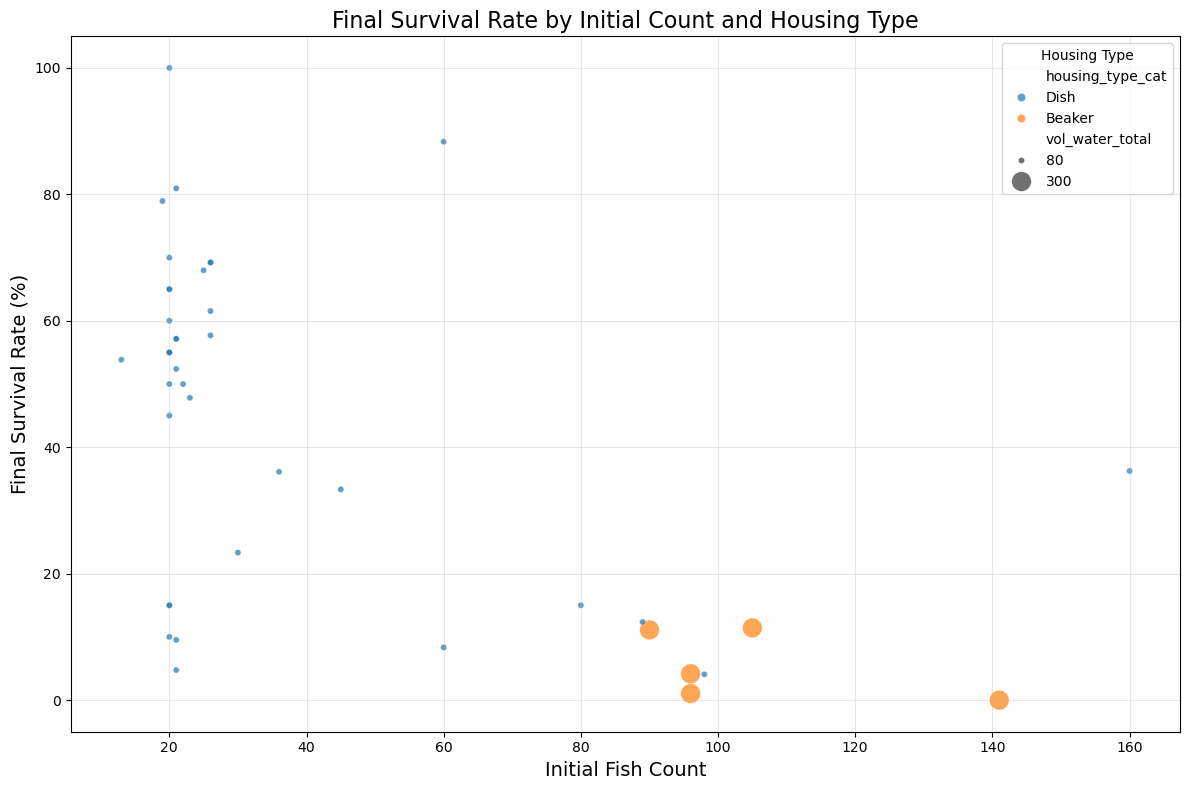

In [226]:
# Filter for only the last observation of each dish
last_observations = df.sort_values('days_since_fertilization').groupby('dish_id').last().reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=last_observations, 
                x='initial_count',
                y='survival_rate', 
                hue='housing_type_cat',
                size='vol_water_total',
                sizes=(20, 200),
                alpha=0.7)

plt.xlabel('Initial Fish Count', fontsize=14)
plt.ylabel('Final Survival Rate (%)', fontsize=14)
plt.title('Final Survival Rate by Initial Count and Housing Type', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(title='Housing Type')
plt.tight_layout()

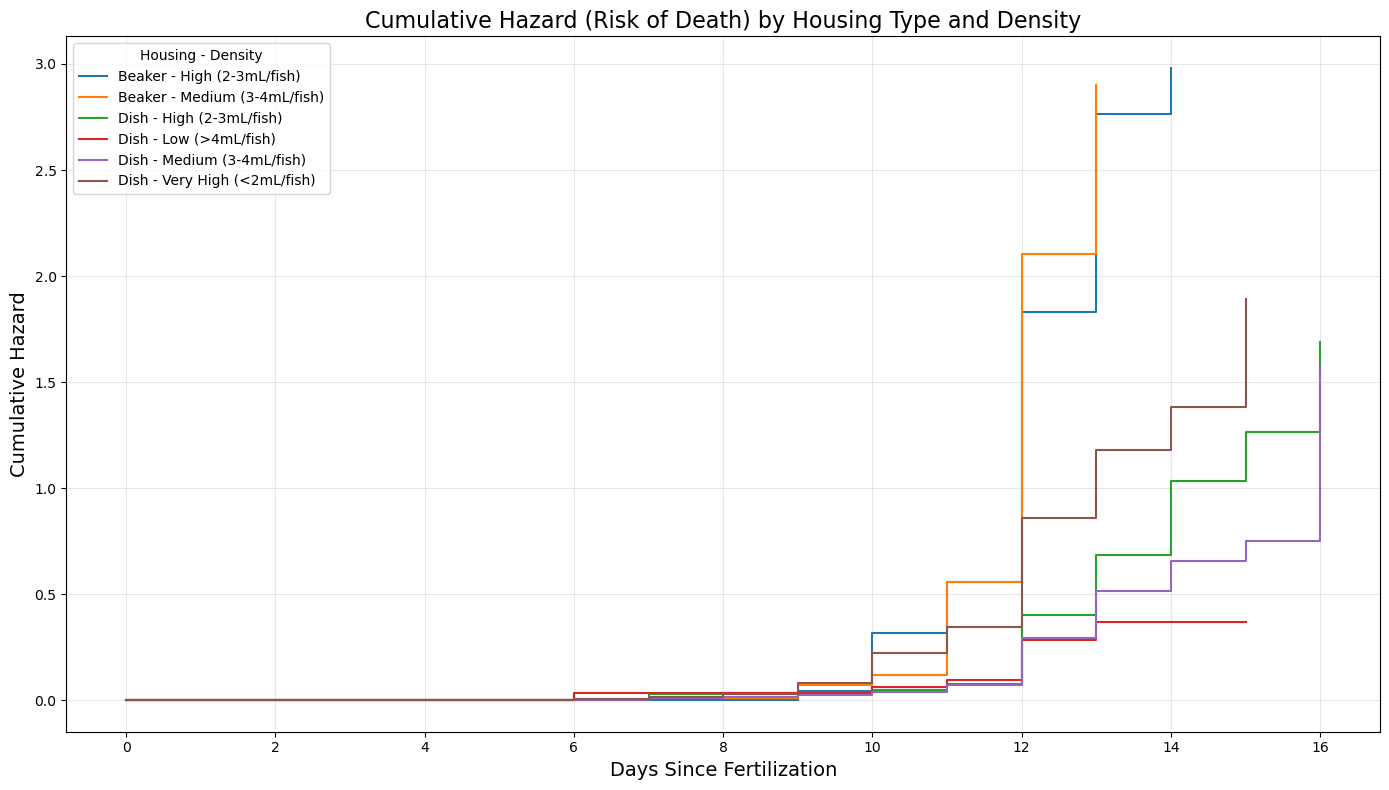

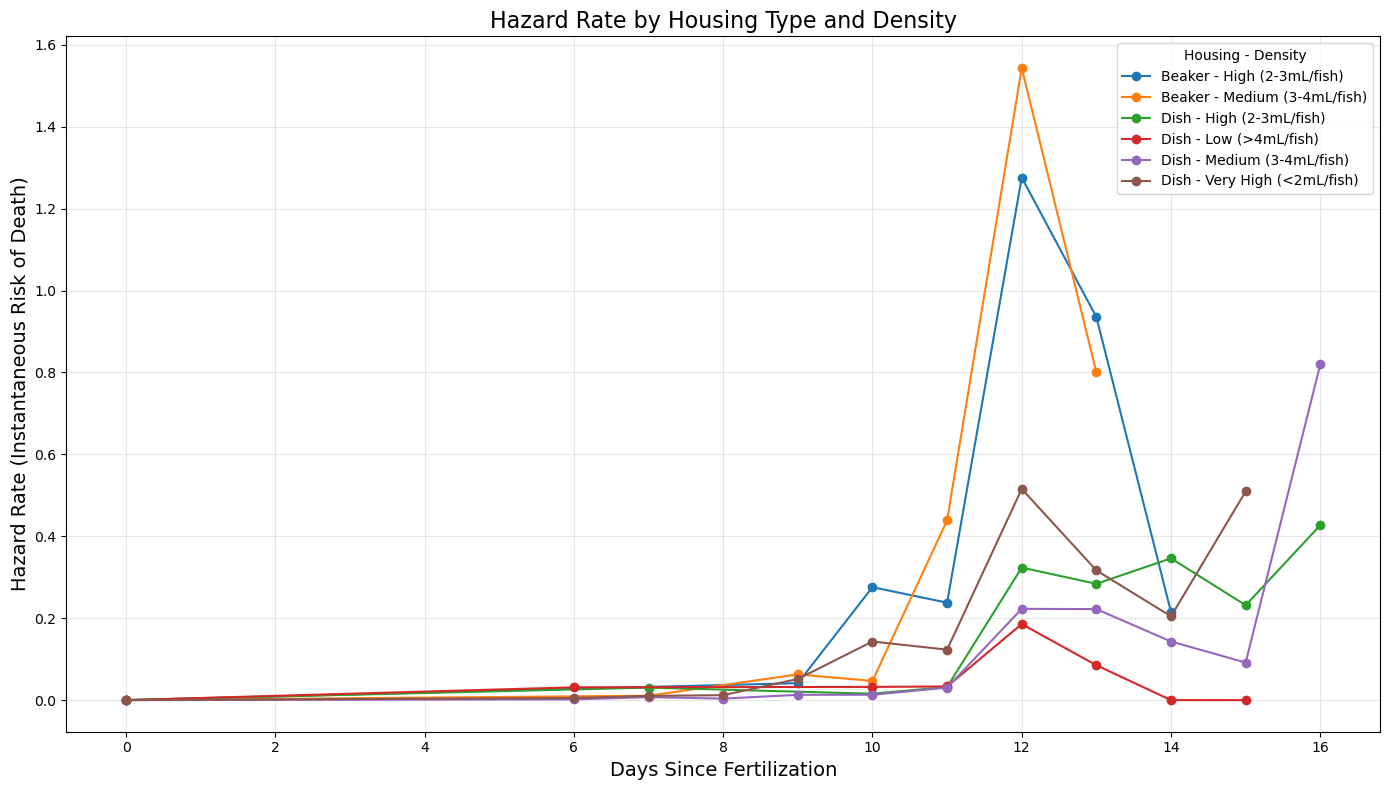

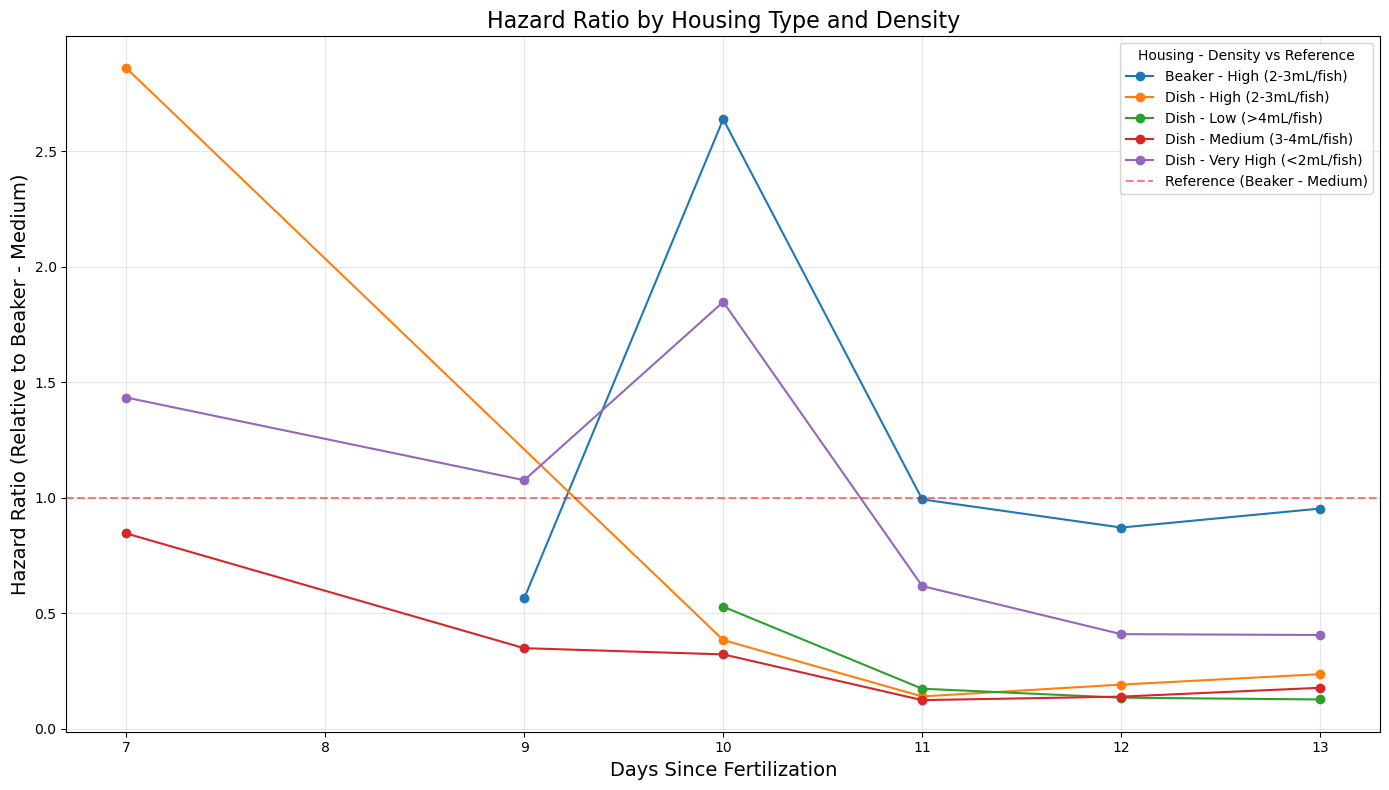

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, NelsonAalenFitter

# Load the data
df = pd.read_csv('derivatives.csv')

# Create proper housing type category with clear labels
df['housing_type_cat'] = df['in_beaker'].replace({'No': 'Dish', 'Yes': 'Beaker'})

# Prepare the data for survival analysis
# We'll create a long-format dataframe where each row represents a fish
# We need to reconstruct deaths at each time point

survival_data = []

# Group by dish_id to track individual dishes over time
for dish_id, dish_data in df.groupby('dish_id'):
    # Sort by days since fertilization
    dish_data = dish_data.sort_values('days_since_fertilization')
    
    # Get metadata from the first row
    genotype = dish_data['genotype'].iloc[0]
    housing_type = dish_data['housing_type_cat'].iloc[0]
    density_category = dish_data['density_category'].iloc[0]
    
    # Get the initial count
    initial_count = dish_data['initial_count'].iloc[0]
    
    # Track the previously observed cumulative deaths
    prev_cum_deaths = 0
    
    # For each time point
    for _, row in dish_data.iterrows():
        days = row['days_since_fertilization']
        cum_deaths = row['cumulative_deaths']
        
        # Calculate new deaths in this period
        new_deaths = cum_deaths - prev_cum_deaths
        
        # Record each death
        for i in range(int(new_deaths)):
            survival_data.append({
                'dish_id': dish_id,
                'genotype': genotype,
                'housing_type': housing_type,
                'density_category': density_category,
                'time': days,
                'event': 1  # 1 indicates death occurred
            })
        
        # Record censored (survived) observations at the last time point
        if days == dish_data['days_since_fertilization'].max():
            remaining = row['remaining']
            for i in range(int(remaining)):
                survival_data.append({
                    'dish_id': dish_id,
                    'genotype': genotype,
                    'housing_type': housing_type,
                    'density_category': density_category,
                    'time': days,
                    'event': 0  # 0 indicates censoring (still alive)
                })
        
        # Update previously observed cumulative deaths
        prev_cum_deaths = cum_deaths

# Create a dataframe from the survival data
survival_df = pd.DataFrame(survival_data)

# Calculate hazard rates using Nelson-Aalen estimator
plt.figure(figsize=(14, 8))

# Group by housing type and density
for (housing, density), group in survival_df.groupby(['housing_type', 'density_category']):
    # Skip groups with insufficient data
    if len(group) < 10:
        continue
    
    # Fit Nelson-Aalen model
    naf = NelsonAalenFitter()
    naf.fit(group['time'], group['event'], label=f"{housing} - {density}")
    
    # Plot the cumulative hazard
    naf.plot_cumulative_hazard(ci_show=False)

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Cumulative Hazard', fontsize=14)
plt.title('Cumulative Hazard (Risk of Death) by Housing Type and Density', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Housing - Density')
plt.tight_layout()

# Now let's calculate the hazard rate (first derivative of cumulative hazard)
plt.figure(figsize=(14, 8))

# Group by housing type and density
for (housing, density), group in survival_df.groupby(['housing_type', 'density_category']):
    # Skip groups with insufficient data
    if len(group) < 10:
        continue
    
    # Fit Nelson-Aalen model
    naf = NelsonAalenFitter()
    naf.fit(group['time'], group['event'])
    
    # Get the cumulative hazard
    cum_hazard = naf.cumulative_hazard_
    
    # Calculate the hazard rate (take the derivative)
    cum_hazard = cum_hazard.sort_index()
    hazard_rate = cum_hazard.diff()
    hazard_rate = hazard_rate.fillna(0)
    
    # Plot the hazard rate
    plt.plot(hazard_rate.index, hazard_rate.iloc[:, 0], 
             marker='o', linewidth=1.5, 
             label=f"{housing} - {density}")

plt.xlabel('Days Since Fertilization', fontsize=14)
plt.ylabel('Hazard Rate (Instantaneous Risk of Death)', fontsize=14)
plt.title('Hazard Rate by Housing Type and Density', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, title='Housing - Density')
plt.tight_layout()

# We can also analyze the hazard ratios between different housing types
# by calculating their relative hazards

plt.figure(figsize=(14, 8))

# Use Beaker - Medium as reference
reference_group = survival_df[(survival_df['housing_type'] == 'Beaker') & 
                             (survival_df['density_category'] == 'Medium (3-4mL/fish)')]

if len(reference_group) >= 10:
    # Fit reference group
    ref_naf = NelsonAalenFitter()
    ref_naf.fit(reference_group['time'], reference_group['event'])
    
    # Get reference cumulative hazard
    ref_cum_hazard = ref_naf.cumulative_hazard_
    
    # Compare other groups to reference
    for (housing, density), group in survival_df.groupby(['housing_type', 'density_category']):
        # Skip reference group and groups with insufficient data
        if housing == 'Beaker' and density == 'Medium (3-4mL/fish)' or len(group) < 10:
            continue
        
        # Fit current group
        curr_naf = NelsonAalenFitter()
        curr_naf.fit(group['time'], group['event'])
        
        # Get current cumulative hazard
        curr_cum_hazard = curr_naf.cumulative_hazard_
        
        # Calculate hazard ratio at each time point
        # Merge the two cumulative hazards
        merged = pd.merge(curr_cum_hazard, ref_cum_hazard, 
                         left_index=True, right_index=True, 
                         how='inner', suffixes=('_curr', '_ref'))
        
        # Calculate the ratio
        merged['ratio'] = merged.iloc[:, 0] / merged.iloc[:, 1]
        
        # Plot the hazard ratio
        plt.plot(merged.index, merged['ratio'], 
                marker='o', linewidth=1.5, 
                label=f"{housing} - {density}")

    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Reference (Beaker - Medium)')
    plt.xlabel('Days Since Fertilization', fontsize=14)
    plt.ylabel('Hazard Ratio (Relative to Beaker - Medium)', fontsize=14)
    plt.title('Hazard Ratio by Housing Type and Density', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10, title='Housing - Density vs Reference')
    plt.tight_layout()